In [1]:
# Standard imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings

from datetime import datetime
from tqdm import tqdm
# import csr_matrix
from scipy.sparse import csr_matrix
# Suppress noisy warnings
warnings.filterwarnings("ignore")

# Plotting configuration (Seaborn + Matplotlib harmony)
sns.set_theme(context="notebook", style="white")  # minimal, clean
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'grid.color': 'white'
})

# Optional: consistent color palette
sns.set_palette("colorblind")

# Print today's date
today = datetime.now().strftime("%Y%m%d")
print(f"Today's date: {today}")

# LeafletFA source code and utilities
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
shared_utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

# Add custom module paths
for path in [src_path, shared_utils_path]:
    if path not in sys.path:
        sys.path.append(path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds
from utils import *
from figure_plotting import *

Today's date: 20250724


In [2]:
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


### To-do: the same thing for human!

In [3]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# Output directory
output_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper"

# Look at all the junctions that are in original anndata (not just the ones used in model training):
SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/072025/aligned_splicing_data_20250723_011203.h5ad"

# Get the ATSE file
ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

# Read in full splice adata 
splice_adata_full = ad.read_h5ad(SPLICE_INPUT)
print(f"Done loading splice adata!")

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
print(f"Done loading ATSE file!")
atse_df.head()

Done loading splice adata!
Done loading ATSE file!


,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,chromosome,strand,atse_start,atse_end,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
0,ENSMUSG00000033845.13_atse_1,ENSMUSG00000033845.13,Mrpl15,protein_coding,3,complex,chr1,-,4782733,4785572,...,0.9996,0.9996,0.9821,2040037,2076419,GT-AG,GT,AG,1.0,0.0
1,ENSMUSG00000033845.13_atse_1,ENSMUSG00000033845.13,Mrpl15,protein_coding,3,complex,chr1,-,4782733,4785572,...,0.0172,0.0172,0.0213,2076419,1674232,GT-AG,GT,AG,1.0,0.0
2,ENSMUSG00000033845.13_atse_1,ENSMUSG00000033845.13,Mrpl15,protein_coding,3,complex,chr1,-,4782733,4785572,...,0.9768,0.9768,0.9983,1674232,1638142,GT-AG,GT,AG,1.0,0.0
3,ENSMUSG00000033845.13_atse_2,ENSMUSG00000033845.13,Mrpl15,protein_coding,2,alternative_3_prime,chr1,-,4777648,4782567,...,0.9738,0.9738,0.9938,1974162,1934475,GT-AG,GT,AG,1.0,0.0
4,ENSMUSG00000033845.13_atse_2,ENSMUSG00000033845.13,Mrpl15,protein_coding,2,alternative_3_prime,chr1,-,4777648,4782567,...,0.0195,0.0195,1.0000,1974162,38508,GT-AG,GT,AG,1.0,0.0


In [4]:
#atse_df = atse_df[["junction_id", "perfect_match_5_prime", "perfect_match_3_prime"]]
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

In [5]:
# Junction ortho mapping
junc_orthos = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/plots_2025-07-05/junction_mapping_mouse_human_with_annotations.csv"
junc_orthos = pd.read_csv(junc_orthos)

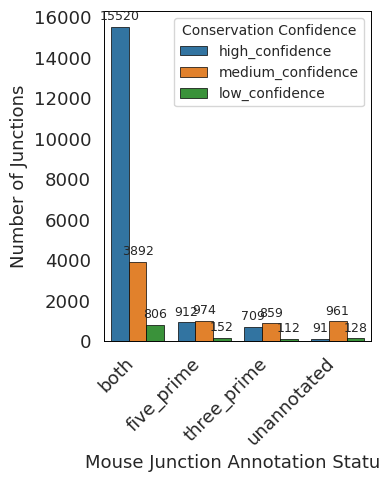

In [6]:
fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sns.countplot(
    data=junc_orthos,
    x="mouse_annotation_status",
    hue="conservation_confidence",
    hue_order=["high_confidence", "medium_confidence", "low_confidence"],
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.set_xlabel("Mouse Junction Annotation Status", fontsize=13)
ax.set_ylabel("Number of Junctions", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

ax.legend(
    title="Conservation Confidence",
    title_fontsize=10,
    fontsize=10,
    loc="upper right",
    frameon=True
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

# Make all spines black
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.7)

plt.tight_layout()
# Save as PDF
plt.savefig(os.path.join(output_dir, f"annotation_status_barplot_{today}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

In [7]:
# Initialize the column with default value
splice_adata_full.var["junction_conserved"] = "conservation_unknown"

# Create set of conserved junction IDs for fast lookup
conserved_junction_ids = set(junc_orthos["mouse_junction_id"])

print(f"Total junctions in splice_adata: {splice_adata_full.var.shape[0]:,}")
print(f"Conserved junctions in mapping: {len(conserved_junction_ids):,}")

# Mark conserved junctions
conserved_mask = splice_adata_full.var["junction_id"].isin(conserved_junction_ids)
splice_adata_full.var.loc[conserved_mask, "junction_conserved"] = "conserved"

# Summary statistics
conserved_count = (splice_adata_full.var["junction_conserved"] == "conserved").sum()
not_conserved_count = (splice_adata_full.var["junction_conserved"] == "conservation_unknown").sum()

print(f"\nConservation labeling results:")
print(f"  Conserved junctions: {conserved_count:,} ({conserved_count/len(splice_adata_full.var)*100:.1f}%)")
print(f"  Not conserved: {not_conserved_count:,} ({not_conserved_count/len(splice_adata_full.var)*100:.1f}%)")

Total junctions in splice_adata: 124,378
Conserved junctions in mapping: 25,116

Conservation labeling results:
  Conserved junctions: 23,040 (18.5%)
  Not conserved: 101,338 (81.5%)


In [8]:
# Ensure clean string format
splice_adata_full.var["annotation_conservation_group"] = (
    splice_adata_full.var["annotation_status"].astype(str) + "_" + splice_adata_full.var["junction_conserved"].astype(str)
)

In [9]:
# Convert age strings like "2m" to integer months
# subset for this analysis to no 2m old cells 
splice_adata_full.obs["age"] = splice_adata_full.obs["age"].str.replace("m", "").astype(int)

# Define young and old groups based on integer age
splice_adata_full.obs["age_group"] = splice_adata_full.obs["age"].apply(
    lambda x: "young" if x in [2, 3] else "old"
)

In [10]:
print("   Computing junction statistics...")
junction_matrix = splice_adata_full.layers["cell_by_junction_matrix"]
        
# Basic expression statistics
splice_adata_full.var["non_zero_count_cells"] = np.array((junction_matrix > 0).sum(axis=0)).flatten()
splice_adata_full.var["non_zero_cell_prop"] = splice_adata_full.var["non_zero_count_cells"] / splice_adata_full.shape[0]

# Total read counts across all cells for each junction
splice_adata_full.var["total_read_counts"] = np.array(junction_matrix.sum(axis=0)).flatten()

# Mean read counts per expressing cell
splice_adata_full.var["mean_counts_per_cell"] = np.where(
    splice_adata_full.var["non_zero_count_cells"] > 0,
    splice_adata_full.var["total_read_counts"] / splice_adata_full.var["non_zero_count_cells"],
    0
)

   Computing junction statistics...


In [11]:
# Calculate summary statistics
non_zero_stats = splice_adata_full.var["non_zero_count_cells"].agg(["min", "max", "mean", "median"])
read_count_stats = splice_adata_full.var["total_read_counts"].agg(["min", "max", "mean", "median"])

# Print formatted summary
print("📊 Junction Detection Summary (Non-zero Count Cells):")
print(f"  Minimum: {non_zero_stats['min']:,}")
print(f"  Maximum: {non_zero_stats['max']:,}")
print(f"  Mean:    {non_zero_stats['mean']:.2f}")
print(f"  Median:  {non_zero_stats['median']:,}")

print("\n📊 Junction Read Count Summary (Total Read Counts):")
print(f"  Minimum: {read_count_stats['min']:,}")
print(f"  Maximum: {read_count_stats['max']:,}")
print(f"  Mean:    {read_count_stats['mean']:.2f}")
print(f"  Median:  {read_count_stats['median']:,}")

📊 Junction Detection Summary (Non-zero Count Cells):
  Minimum: 0.0
  Maximum: 132,249.0
  Mean:    4725.68
  Median:  419.0

📊 Junction Read Count Summary (Total Read Counts):
  Minimum: 0.0
  Maximum: 59,228,194.0
  Mean:    87091.51
  Median:  3,123.0


In [12]:
# print junctions that have zero non_zero_count_cells or total_read_counts
splice_adata_full.var[(splice_adata_full.var["non_zero_count_cells"] == 0) | (splice_adata_full.var["total_read_counts"] == 0)]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,junction_conserved,annotation_conservation_group,non_zero_count_cells,non_zero_cell_prop,total_read_counts,mean_counts_per_cell
1292,chr10_127991465_127994471_-,ENSMUSG00000025396.7_atse_3,GT-AG,three_prime,HSD17B6,ENSMUSG00000025396.7,6,21.0,0.0,483,1292,0,low,conservation_unknown,three_prime_conservation_unknown,0,0.0,0,0.0
42070,chr15_7140583_7154108_+,ENSMUSG00000054263.12_atse_1,GT-AG,five_prime,LIFR,ENSMUSG00000054263.12,8,0.0,NaN,140,42070,0,low,conservation_unknown,five_prime_conservation_unknown,0,0.0,0,0.0
47528,chr16_29479802_29490009_-,ENSMUSG00000038094.15_atse_2,GT-AG,both,ATP13A4,ENSMUSG00000038094.15,3,1.0,0.0,151,47528,0,low,conservation_unknown,both_conservation_unknown,0,0.0,0,0.0
50652,chr16_93920037_93929372_-,ENSMUSG00000047109.13_atse_1,GT-AG,three_prime,CLDN14,ENSMUSG00000047109.13,5,-3.0,0.0,199,50652,0,low,conservation_unknown,three_prime_conservation_unknown,0,0.0,0,0.0
66979,chr19_7926783_7965720_-,ENSMUSG00000067656.13_atse_1,GT-AG,unannotated,SLC22A27,ENSMUSG00000067656.13,14,NaN,28.0,126,66979,0,low,conservation_unknown,unannotated_conservation_unknown,0,0.0,0,0.0
98308,chr4_104865547_104876408_-,ENSMUSG00000035031.15_atse_1,GT-AG,three_prime,C8A,ENSMUSG00000035031.15,5,NaN,0.0,354,98308,1,low,conservation_unknown,three_prime_conservation_unknown,0,0.0,0,0.0
99073,chr4_115433137_115433466_+,ENSMUSG00000078597.2_atse_2,GT-AG,three_prime,CYP4A12B,ENSMUSG00000078597.2,2,NaN,1.0,1052,99073,1,low,conservation_unknown,three_prime_conservation_unknown,0,0.0,0,0.0
121783,chr6_141909143_141911810_-,ENSMUSG00000041698.11_atse_2,GT-AG,five_prime,SLCO1A1,ENSMUSG00000041698.11,2,1.0,-13.0,615,121783,0,low,conservation_unknown,five_prime_conservation_unknown,0,0.0,0,0.0
133170,chr7_26061844_26080597_+,ENSMUSG00000040583.8_atse_1,GT-AG,three_prime,CYP2B13,ENSMUSG00000040583.8,3,NaN,1.0,106,133170,0,low,conservation_unknown,three_prime_conservation_unknown,0,0.0,0,0.0


In [13]:
splice_adata_full.var.sort_values(by="total_read_counts", ascending=False)

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,junction_conserved,annotation_conservation_group,non_zero_count_cells,non_zero_cell_prop,total_read_counts,mean_counts_per_cell
54939,chr17_35266303_35266481_+,ENSMUSG00000073411.11_atse_10,GT-AG,both,H2-D1,ENSMUSG00000073411.11,2,0.0,1.0,91941488,54939,107581,high,conservation_unknown,both_conservation_unknown,104978,0.732902,59228194,564.196251
149716,chr9_120130363_120130767_+,ENSMUSG00000032518.6_atse_7,GT-AG,both,RPSA,ENSMUSG00000032518.6,2,0.0,1.0,69848836,149716,128397,high,conservation_unknown,both_conservation_unknown,125442,0.875771,46094554,367.457104
111394,chr5_125387301_125387757_-,ENSMUSG00000008348.9_atse_1,GT-AG,unannotated,UBC,ENSMUSG00000008348.9,2,-98.0,NaN,59689739,111394,126712,high,conserved,unannotated_conserved,123861,0.864734,43062413,347.667248
132586,chr7_19697647_19698187_-,ENSMUSG00000002985.16_atse_3,GT-AG,both,APOE,ENSMUSG00000002985.16,2,1.0,0.0,74569178,132586,51986,high,conservation_unknown,both_conservation_unknown,51194,0.357410,42918981,838.359593
131527,chr7_142678858_142679346_-,ENSMUSG00000000215.11_atse_4,GT-AG,both,INS2,ENSMUSG00000000215.11,2,1.0,0.0,126232042,131527,10413,high,conservation_unknown,both_conservation_unknown,9971,0.069612,38312641,3842.407081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121783,chr6_141909143_141911810_-,ENSMUSG00000041698.11_atse_2,GT-AG,five_prime,SLCO1A1,ENSMUSG00000041698.11,2,1.0,-13.0,615,121783,0,low,conservation_unknown,five_prime_conservation_unknown,0,0.000000,0,0.000000
66979,chr19_7926783_7965720_-,ENSMUSG00000067656.13_atse_1,GT-AG,unannotated,SLC22A27,ENSMUSG00000067656.13,14,NaN,28.0,126,66979,0,low,conservation_unknown,unannotated_conservation_unknown,0,0.000000,0,0.000000
50652,chr16_93920037_93929372_-,ENSMUSG00000047109.13_atse_1,GT-AG,three_prime,CLDN14,ENSMUSG00000047109.13,5,-3.0,0.0,199,50652,0,low,conservation_unknown,three_prime_conservation_unknown,0,0.000000,0,0.000000
47528,chr16_29479802_29490009_-,ENSMUSG00000038094.15_atse_2,GT-AG,both,ATP13A4,ENSMUSG00000038094.15,3,1.0,0.0,151,47528,0,low,conservation_unknown,both_conservation_unknown,0,0.000000,0,0.000000


Unique transcripts: ['ENSMUST00000035105.6', 'ENSMUST00000217317.1', 'ENSMUST00000217352.1', 'ENSMUST00000217356.1']
Unique transcripts to remove: []
Plot saved to mouse_ENSMUSG00000032518.6_atse_7.pdf!


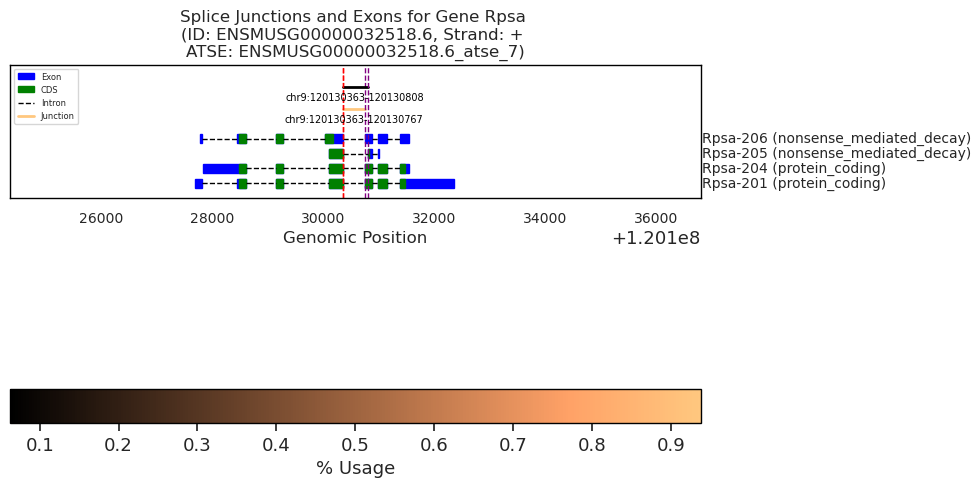

ATSE visualization saved: mouse_ENSMUSG00000032518.6_atse_7.pdf


{'junctions':                           event_id               gene_id gene_name  \
 45385  ENSMUSG00000032518.6_atse_7  ENSMUSG00000032518.6      Rpsa   
 45386  ENSMUSG00000032518.6_atse_7  ENSMUSG00000032518.6      Rpsa   
 
            gene_types  num_junctions           event_type chromosome strand  \
 45385  protein_coding              2  alternative_3_prime       chr9      +   
 45386  protein_coding              2  alternative_3_prime       chr9      +   
 
        atse_start   atse_end  ...  donor_total_reads  acceptor_total_reads  \
 45385   120130363  120130808  ...           74499345              69850913   
 45386   120130363  120130808  ...           74499345               4645177   
 
        splice_motif  donor_seq  acceptor_seq  position_off_5_prime  \
 45385         GT-AG         GT            AG                   0.0   
 45386         GT-AG         GT            AG                   0.0   
 
       position_off_3_prime junction_annotation usage_ratio  \
 45385       

In [14]:
mouse_event = "ENSMUSG00000032518.6_atse_7"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", show_usage=True,
                show_junc_lines=True)

In [15]:
from scipy.sparse import csr_matrix
import numpy as np

# Get matrices
A = splice_adata_full.layers["cell_by_junction_matrix"].tocsr()
B = splice_adata_full.layers["cell_by_cluster_matrix"].tocsr()

# Sanity check: same sparsity structure
assert np.array_equal(A.indices, B.indices), "Mismatch in indices"
assert np.array_equal(A.indptr, B.indptr), "Mismatch in indptr"

# Element-wise safe division
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_data = np.true_divide(A.data, B.data)
    #ratio_data[~np.isfinite(ratio_data)] = 0.0  # Replace NaN or inf with 0.0

# Reconstruct CSR matrix
junc_ratio_csr = csr_matrix((ratio_data, A.indices, A.indptr), shape=A.shape)

# Store in AnnData
splice_adata_full.layers["junc_ratio"] = junc_ratio_csr
splice_adata_full.layers["junc_ratio"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1534075705 stored elements and shape (143236, 124378)>

### Make the same plot but showing raw junction read counts

In [16]:
# View counts per group
print(splice_adata_full.obs["age_group"].value_counts())

age_group
young    87465
old      55771
Name: count, dtype: int64


In [17]:
# Metadata
obs = splice_adata_full.obs.copy()
var = splice_adata_full.var
meta = obs[["age", "tissue"]].copy()
meta["age"] = meta["age"].astype(int)

# Matrix layers
psi_layer = splice_adata_full.layers["junc_ratio"]
count_layer = splice_adata_full.layers["cell_by_junction_matrix"]

# Group masks (used for sparse read count slices)
young_mask = obs["age_group"] == "young"
old_mask = obs["age_group"] == "old"

In [46]:
# Initialize container
delta_by_tissue = {}

# Step 1: Loop through tissues
for tissue in splice_adata_full.obs["broad_cell_type"].unique():
    if tissue == "Neuron":
        print(f"Skipping {tissue}")
        continue
    
    tissue_mask = splice_adata_full.obs["broad_cell_type"] == tissue
    young_mask = tissue_mask & (splice_adata_full.obs["age_group"] == "young")
    old_mask = tissue_mask & (splice_adata_full.obs["age_group"] == "old")

    # Skip tissues with too few cells in either group
    if young_mask.sum() < 100 or old_mask.sum() < 100:
        print(f"Skipping {tissue}")
        continue

    psi_young = splice_adata_full[young_mask].layers["junc_ratio"]
    psi_old = splice_adata_full[old_mask].layers["junc_ratio"]

    # Compute mean across cells (axis=0); result is 1 x n_junctions sparse matrix
    mean_psi_young = psi_young.mean(axis=0).A1  # convert to flat array
    mean_psi_old = psi_old.mean(axis=0).A1

    # ΔPSI
    delta = mean_psi_old - mean_psi_young
    print(f"Found {np.sum(delta > 0.025)} positive and {np.sum(delta < -0.025)} negative values in delta for {tissue} using 0.025 threshold...")
    delta_by_tissue[tissue] = delta

# Step 2: Assemble tissue ΔPSIs into DataFrame
delta_df = pd.DataFrame(delta_by_tissue)  # shape: [n_junctions x n_tissues]
delta_df["junction_id"] = splice_adata_full.var["junction_id"].values

# Step 3: Merge into psi_summary
psi_summary = pd.DataFrame({
    "junction_id": splice_adata_full.var["junction_id"].values
})
psi_summary = psi_summary.merge(delta_df, on="junction_id")

# Step 4: Compute overall median ΔPSI across tissues
tissue_cols = [col for col in psi_summary.columns if col not in ["junction_id"]]
psi_summary["median_delta_psi_across_tissues"] = psi_summary[tissue_cols].median(axis=1)
psi_summary["max_delta_psi_across_tissues"] = psi_summary[tissue_cols].max(axis=1)
psi_summary["max_abs_delta_psi_across_tissues"] = psi_summary[tissue_cols].abs().max(axis=1)
psi_summary["delta_psi_variance_across_cell_types"] = psi_summary[tissue_cols].var(axis=1)

# Get median delta psi variance across cell types and label global vs specific using median variance value
median_variance = psi_summary["delta_psi_variance_across_cell_types"].median()
psi_summary["delta_psi_variance"] = psi_summary["delta_psi_variance_across_cell_types"].apply(lambda x: "global" if x < median_variance else "specific")

Found 383 positive and 7457 negative values in delta for Epithelial cell using 0.025 threshold...
Found 415 positive and 1096 negative values in delta for Immune cell using 0.025 threshold...
Found 60 positive and 3455 negative values in delta for Vascular cell using 0.025 threshold...
Found 612 positive and 3226 negative values in delta for Muscle cell using 0.025 threshold...
Found 521 positive and 5239 negative values in delta for Stem cell using 0.025 threshold...
Found 346 positive and 4359 negative values in delta for Stromal cell using 0.025 threshold...
Found 13770 positive and 696 negative values in delta for Secretory cell using 0.025 threshold...
Found 443 positive and 5051 negative values in delta for Cardiac cell using 0.025 threshold...
Found 55 positive and 13554 negative values in delta for Pancreatic cell using 0.025 threshold...
Found 332 positive and 6544 negative values in delta for Glial cell using 0.025 threshold...
Found 296 positive and 4093 negative values in d

### Find exon skipping junctions

In [19]:
# Subset to ATSEs with exactly 3 junctions
atse_counts = splice_adata_full.var.groupby("event_id")["junction_id"].count()
candidate_atse = atse_counts[atse_counts == 3].index

# Pull junctions from those candidate ATSEs
subset = splice_adata_full.var[splice_adata_full.var["event_id"].isin(candidate_atse)].copy()

# Sort them by event_id and junction start
subset[["chr", "start", "end", "strand"]] = subset["junction_id"].str.extract(r"(chr[\w]+)_(\d+)_(\d+)_([+-])")
subset["start"] = subset["start"].astype(int)
subset["end"] = subset["end"].astype(int)
subset["event_id"] = subset["event_id"].astype(str)
subset["atse_event"] = "exon_skipping"

# Wrap the groupby apply with tqdm
grouped = subset.groupby("event_id")
results = []
for name, group in tqdm(grouped, total=len(grouped)):
    group = group.sort_values(["start", "end"])
    group["span"] = group["end"] - group["start"]
    group["skip_junction"] = group["span"] == group["span"].max()
    results.append(group)

subset = pd.concat(results)

100%|██████████| 9890/9890 [00:48<00:00, 204.20it/s]


In [20]:
# 1. Merge ΔPSI summary with junction metadata
psi_summary = psi_summary.merge(
    splice_adata_full.var[[
        "junction_id", "annotation_status", "junction_conserved",
        "total_read_counts", "non_zero_count_cells", "num_junctions",
        "non_zero_cell_prop", "mean_counts_per_cell"
    ]],
    on="junction_id",
    how="left"
)

In [21]:
# 3. Simplify annotation category
psi_summary["annotation_group"] = np.where(
    psi_summary["annotation_status"] == "both",
    "annotated",
    "unannotated"
)

# 4. Create combined label
psi_summary["annot_conserved"] = (
    psi_summary["annotation_group"] + " | " + psi_summary["junction_conserved"]
)

# 5. Add exon skipping flag if available
psi_summary["junction_id"] = psi_summary["junction_id"].astype(str)
subset["junction_id"] = subset["junction_id"].astype(str)

psi_summary = psi_summary.merge(
    subset[["junction_id", "skip_junction", "atse_event"]],
    on="junction_id",
    how="left"
)
psi_summary["skip_junction"] = psi_summary["skip_junction"].fillna(False)

In [22]:
psi_summary.sort_values(by="max_abs_delta_psi_across_tissues")

,junction_id,Epithelial cell,Immune cell,Vascular cell,Muscle cell,Stem cell,Stromal cell,Secretory cell,Cardiac cell,Pancreatic cell,...,junction_conserved,total_read_counts,non_zero_count_cells,num_junctions,non_zero_cell_prop,mean_counts_per_cell,annotation_group,annot_conserved,skip_junction,atse_event
124377,chrY_942917_956684_+,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,conservation_unknown,128,35,2,0.000244,3.657143,unannotated,unannotated | conservation_unknown,False,NaN
86034,chr5_138297425_138297965_+,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,conservation_unknown,117,34,3,0.000237,3.441176,annotated,annotated | conservation_unknown,True,exon_skipping
25341,chr14_123885989_124132462_-,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,conservation_unknown,829,219,2,0.001529,3.785388,unannotated,unannotated | conservation_unknown,False,NaN
64936,chr2_25905378_25905485_+,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,conservation_unknown,228,84,3,0.000586,2.714286,unannotated,unannotated | conservation_unknown,False,exon_skipping
25345,chr14_124136292_124276757_-,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,conservation_unknown,162,52,6,0.000363,3.115385,unannotated,unannotated | conservation_unknown,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90007,chr5_77355671_77407539_-,-0.037130,0.012388,0.013297,-0.024367,-0.010644,0.077588,-0.018624,-0.041481,-0.251269,...,conserved,13793027,38255,2,0.267077,360.554882,annotated,annotated | conserved,False,NaN
1407,chr10_128909958_128910394_+,-0.033820,0.019187,-0.047057,-0.153269,0.061938,0.038658,0.187108,0.056193,-0.176160,...,conserved,12436894,60456,2,0.422073,205.718109,annotated,annotated | conserved,False,NaN
29346,chr15_101271865_101272152_+,-0.063349,-0.036293,-0.027277,-0.057018,-0.044350,-0.006711,0.304772,-0.043809,-0.058120,...,conserved,3598880,41414,2,0.289131,86.900082,annotated,annotated | conserved,False,NaN
101391,chr7_19307440_19309305_-,-0.131239,-0.033538,-0.069404,-0.163002,-0.152769,-0.089066,0.106360,-0.000801,-0.060162,...,conserved,436182,13137,2,0.091716,33.202558,annotated,annotated | conserved,False,NaN


In [23]:
def plot_junction_usage_by_celltype_and_age(splice_adata, junc_idx):
    junc_id = splice_adata.var["junction_id"].iloc[junc_idx]
    
    # Extract PSI for the junction from sparse matrix
    psi = splice_adata.layers["junc_ratio"][:, junc_idx].toarray().ravel()
    
    # Build dataframe
    df = pd.DataFrame({
        "PSI": psi,
        "cell_type": splice_adata.obs["broad_cell_type"].values,
        "age_group": splice_adata.obs["age_group"].values,
        "age": splice_adata.obs["age"].values
    })

    # Keep only finite non NA values
    df = df[df["PSI"].notna()]

    # Filter to cell types with PSI detected in both age groups
    valid_cell_types = (
        df.groupby(["cell_type", "age_group"]).size()
        .unstack(fill_value=0)
        .query("young >= 10 and old >= 10")
        .index.tolist()
    )
    df = df[df["cell_type"].isin(valid_cell_types)]
    
    # Drop unused categories (optional but cleaner plot)
    df["cell_type"] = df["cell_type"].astype("category")
    df["cell_type"] = df["cell_type"].cat.remove_unused_categories()
    
    # Order by median PSI across all cells
    ordered_cell_types = df.groupby("cell_type")["PSI"].median().sort_values(ascending=False).index.tolist()
    print(df["cell_type"].value_counts())

    # Plot
    plt.figure(figsize=(10, 5))
    ax = sns.violinplot(
        data=df, 
        x="cell_type", 
        y="PSI", 
        hue="age_group", 
        order=ordered_cell_types,
        split=True, 
        inner="box"
    )
    
    # Annotate means
    means = df.groupby(["cell_type", "age_group"])["PSI"].mean().unstack()
    for i, ct in enumerate(ordered_cell_types):
        for j, ag in enumerate(["young", "old"]):
            if ag in means.columns:
                mean_val = means.loc[ct, ag]
                offset = 0.15 if ag == "young" else -0.15
                ax.text(i + offset, mean_val + 0.02, f"{mean_val:.2f}", 
                        ha='center', va='bottom', fontsize=8, color="red")

    # Format
    plt.title(f"Junction PSI Usage: {junc_id}")
    plt.ylabel("PSI (Detected cells only)")
    plt.xlabel("Cell Type")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.legend(title="Age Group")
    plt.show()

cell_type
Neuron              48930
Immune cell         28187
Epithelial cell     15674
Glial cell          14618
Stem cell            9112
Vascular cell        7959
Stromal cell         5810
Muscle cell          5090
Pancreatic cell      2262
Intestinal cell      1515
Bladder cell          764
Liver cell            733
Cardiac cell          609
Secretory cell        324
Lung cell             258
Fenestrated cell      241
Kidney cell           222
Name: count, dtype: int64


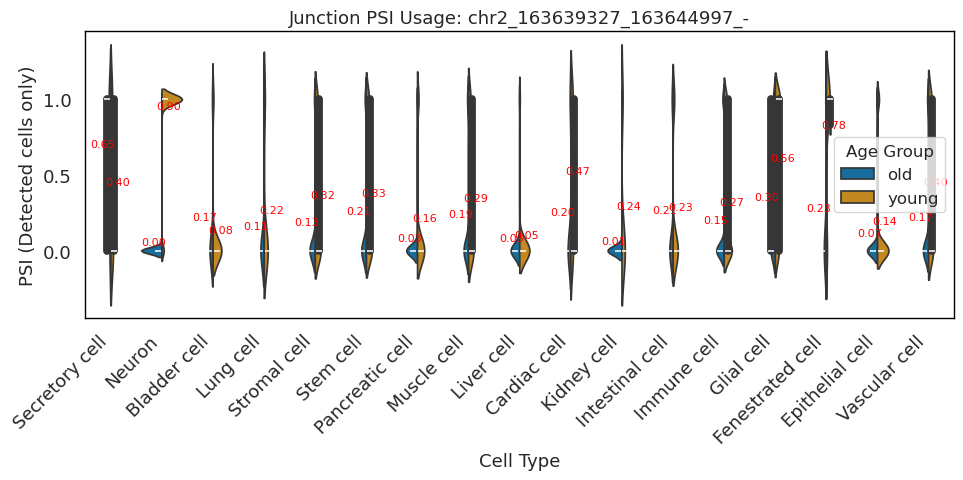

In [24]:
plot_junction_usage_by_celltype_and_age(splice_adata_full, junc_idx=62885)

In [27]:
psi_summary.iloc[1]

junction_id                                  chr10_100016155_100051845_+
Epithelial cell                                                -0.002316
Immune cell                                                     0.000106
Vascular cell                                                  -0.004044
Muscle cell                                                     0.001398
Stem cell                                                      -0.002016
Stromal cell                                                     0.00032
Secretory cell                                                       0.0
Cardiac cell                                                   -0.005026
Pancreatic cell                                                 0.000858
Glial cell                                                     -0.000963
Liver cell                                                      0.001901
Fenestrated cell                                               -0.003356
Intestinal cell                                    

In [28]:
# Summary statistics
print(psi_summary["max_abs_delta_psi_across_tissues"].describe())
psi_summary["abs_delta_psi"] = psi_summary["max_abs_delta_psi_across_tissues"]

# % of junctions with high ΔPSI (e.g., >0.05)
high_delta_frac = (psi_summary["abs_delta_psi"] > 0.05).mean()
print(f"Fraction of junctions with |ΔPSI| > 0.05: {high_delta_frac:.2%}")

# Spearman correlation: ΔPSI vs # of cells with non-zero PSI
rho_cells = psi_summary["abs_delta_psi"].corr(psi_summary["non_zero_count_cells"], method="spearman")
rho_reads = psi_summary["abs_delta_psi"].corr(psi_summary["total_read_counts"], method="spearman")

print(f"Spearman ρ (|ΔPSI| vs non-zero cell count): {rho_cells:.2f}")
print(f"Spearman ρ (|ΔPSI| vs read count): {rho_reads:.2f}")

count    124378.000000
mean          0.022068
std           0.046313
min           0.000000
25%           0.000858
50%           0.005395
75%           0.019516
max           0.546289
Name: max_abs_delta_psi_across_tissues, dtype: float64
Fraction of junctions with |ΔPSI| > 0.05: 12.54%
Spearman ρ (|ΔPSI| vs non-zero cell count): 0.70
Spearman ρ (|ΔPSI| vs read count): 0.78


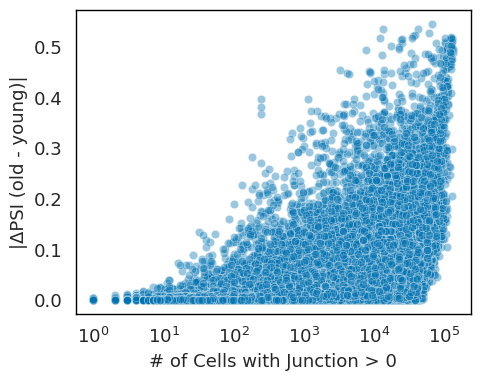

In [29]:
plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=psi_summary,
    x="non_zero_count_cells",
    y="abs_delta_psi",
    alpha=0.4
)
plt.xscale("log")
plt.ylabel("|ΔPSI (old - young)|")
plt.xlabel("# of Cells with Junction > 0")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "cells_wjunc_vs_delta_psi.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [30]:
# Spearman correlation: ΔPSI vs # of cells with non-zero PSI
rho_ATSE = psi_summary["abs_delta_psi"].corr(psi_summary["non_zero_count_cells"], method="spearman")
print(f"Spearman ρ (|ΔPSI| vs non_zero_count_cells): {rho_ATSE:.2f}")

Spearman ρ (|ΔPSI| vs non_zero_count_cells): 0.70


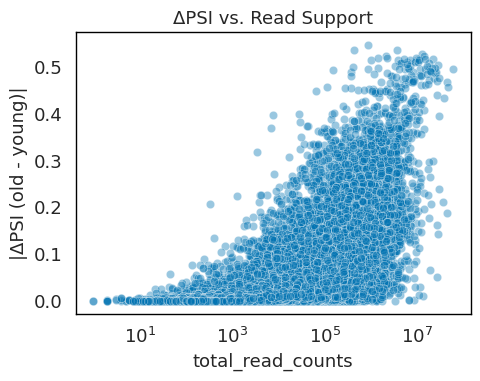

In [31]:
plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=psi_summary,
    x="total_read_counts",
    y="abs_delta_psi",
    alpha=0.4
)
plt.xscale("log")
plt.ylabel("Total Junction Read Counts")
plt.ylabel("|ΔPSI (old - young)|")
plt.title("ΔPSI vs. Read Support")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "total_junc_reads_wjunc_vs_delta_psi.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [32]:
# Spearman correlation: ΔPSI vs # of cells with non-zero PSI
rho_ATSE = psi_summary["abs_delta_psi"].corr(psi_summary["num_junctions"], method="spearman")

print(f"Spearman ρ (|ΔPSI| vs num_junctions in ATSE): {rho_ATSE:.2f}")

Spearman ρ (|ΔPSI| vs num_junctions in ATSE): -0.23


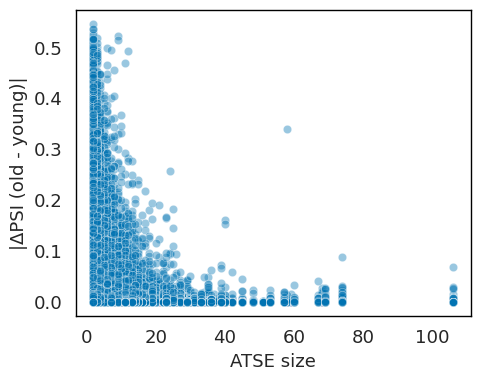

In [33]:
plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=psi_summary,
    x="num_junctions",
    y="abs_delta_psi",
    alpha=0.4
)
#plt.xscale("log")
plt.ylabel("|ΔPSI (old - young)|")
plt.xlabel("ATSE size")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "ATSE_size_vs_delta_psi.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [36]:
# Make a copy to work with
df = psi_summary.copy()

# Bin coverage: use non-zero cell count or total reads
df["coverage_bin"] = pd.qcut(df["non_zero_count_cells"], q=3, labels=["low", "medium", "high"])

File saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_coverage_vs_annotation_status_20250724.pdf


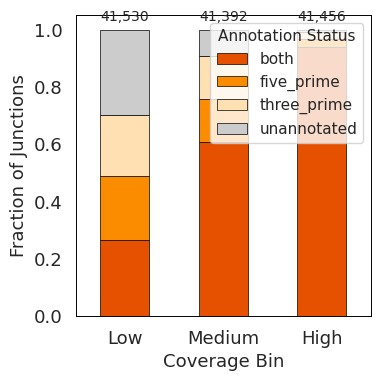

annotation_status   both  five_prime  three_prime  unannotated
coverage_bin                                                  
low                11003        9326         8826        12375
medium             25174        6194         6136         3888
high               38984        1082         1070          320


In [37]:
# ---------- Data Aggregation ----------
# Get counts of annotation_status within each coverage_bin
coverage_counts = (
    df.groupby(["coverage_bin", "annotation_status"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["low", "medium", "high"], fill_value=0)  # Ensure bin order
)

# Compute row-wise fractions
coverage_frac = coverage_counts.div(coverage_counts.sum(axis=1), axis=0)

# ---------- Plot Setup ----------
fig, ax = plt.subplots(figsize=(4, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Use distinct shades for annotation status
annotation_colors = {
    "both": "#e65100",
    "five_prime": "#fb8c00",
    "three_prime": "#ffe0b2",
    "unannotated": "#ccc"
}
# Match column order to colors
annotation_order = ["both", "five_prime", "three_prime", "unannotated"]

bar_container = coverage_frac[annotation_order].plot(
    kind="bar",
    stacked=True,
    color=[annotation_colors[k] for k in annotation_order],
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---------- Axis and Labels ----------
ax.set_ylabel("Fraction of Junctions", fontsize=13)
ax.set_xlabel("Coverage Bin", fontsize=13)
ax.set_xticklabels(["Low", "Medium", "High"], rotation=0, fontsize=13)
ax.legend(title="Annotation Status", title_fontsize=11, fontsize=11, loc="upper right", frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# ---------- Add total junction count on top of bars ----------
total_junctions_per_bin = coverage_counts.sum(axis=1)
for i, (bin_label, count) in enumerate(total_junctions_per_bin.items()):
    ax.text(i, 1.02, f"{count:,}", ha="center", va="bottom", fontsize=10)

# ---------- Set spines ----------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

# ---------- Save ----------
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"mouse_coverage_vs_annotation_status_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"File saved to {os.path.join(output_dir, f'mouse_coverage_vs_annotation_status_{today}.pdf')}")
plt.show()

# ---------- Optional Debug ----------
print(coverage_counts)

coverage_bin         low  medium   high
annotation_status                      
both               11003   25174  38984
five_prime          9326    6194   1082
three_prime         8826    6136   1070
unannotated        12375    3888    320
File saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_annotation_status_vs_coverage.pdf


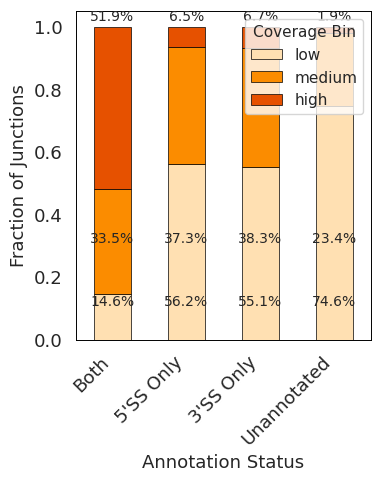

In [38]:
# ---------- Data Aggregation ----------
coverage_counts = (
    df.groupby(["annotation_status", "coverage_bin"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["low", "medium", "high"], fill_value=0)  # ensure order
)

coverage_frac = coverage_counts.div(coverage_counts.sum(axis=1), axis=0)

# ---------- Plot Setup ----------
fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# colors make three shades of orange since orange is color for mouse 
colors = ["#ffe0b2", "#fb8c00", "#e65100"]

bar_container = coverage_frac.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---------- Axis and Labels ----------
ax.set_ylabel("Fraction of Junctions", fontsize=13)
ax.set_xlabel("Annotation Status", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
# Place legend on the right
ax.legend(title="Coverage Bin", title_fontsize=11, fontsize=11, loc="upper right", frameon=True) 
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# ---------- Add fraction labels on top of high bin ----------
# Show percentage of junctions in each bin
for i, status in enumerate(coverage_frac.index):
    frac = coverage_frac.loc[status, "high"]
    total = coverage_counts.loc[status].sum()
    percent = frac * 100
    ax.text(i, 1.01, f"{percent:.1f}%", ha="center", va="bottom", fontsize=10)
    # show medium and low
    frac_medium = coverage_frac.loc[status, "medium"]
    percent_medium = frac_medium * 100
    ax.text(i, 0.3, f"{percent_medium:.1f}%", ha="center", va="bottom", fontsize=10)
    frac_low = coverage_frac.loc[status, "low"]
    percent_low = frac_low * 100
    ax.text(i, 0.1, f"{percent_low:.1f}%", ha="center", va="bottom", fontsize=10)

# ---------- Set spines ----------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

# Rename xaxis labels to "Both", "5'SS Only", "3'SS Only", "Unannotated"
ax.set_xticklabels(["Both", "5'SS Only", "3'SS Only", "Unannotated"])

# Over ride legend position to put it outside of the plot on the right 
ax.legend(title="Coverage Bin", title_fontsize=11, fontsize=11, loc="upper right", frameon=True)

# Print breakdown of coverage by annotation status
print(coverage_counts)

# ---------- Save ----------
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "mouse_annotation_status_vs_coverage.pdf"), format="pdf", bbox_inches="tight")
print(f"File saved to {os.path.join(output_dir, 'mouse_annotation_status_vs_coverage.pdf')}")
plt.show()


In [44]:
df["delta_psi_category"].value_counts()

delta_psi_category
between -0.05 and 0.05    113581
> 0.05                     10796
< -0.05                        1
Name: count, dtype: int64

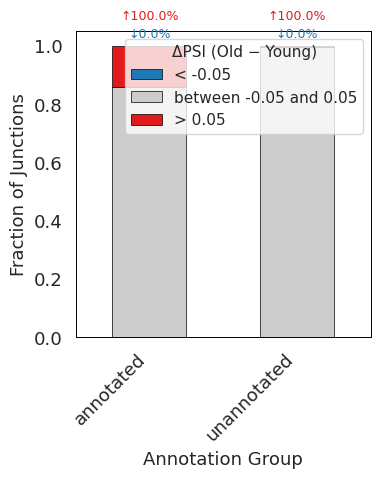

In [39]:
# Only keep rows with valid ΔPSI
df = df[df["max_delta_psi_across_tissues"].notna()]

# Step 1: Categorize ΔPSI with direction preserved
def categorize_delta(val):
    if pd.isna(val):
        return "NaN"
    elif val < -0.05:
        return "< -0.05"
    elif val > 0.05:
        return "> 0.05"
    else:
        return "between -0.05 and 0.05"

df["delta_psi_category"] = df["max_delta_psi_across_tissues"].apply(categorize_delta)

# Step 2: Use `annotation_group` instead of `annotation_status`
delta_counts = (
    df.groupby(["annotation_group", "delta_psi_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["< -0.05", "between -0.05 and 0.05", "> 0.05"], fill_value=0)
)

# Normalize to fractions
delta_frac = delta_counts.div(delta_counts.sum(axis=1), axis=0)

# Step 3: Plot settings
fig, ax = plt.subplots(figsize=(4,5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Color palette
colors = {
    "< -0.05": "#1f78b4",                  # Blue
    "between -0.05 and 0.05": "#cccccc",   # Gray
    "> 0.05": "#e31a1c",                   # Red
}

# Stacked barplot
delta_frac.plot(
    kind="bar",
    stacked=True,
    color=[colors[c] for c in delta_frac.columns],
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Axis labels and formatting
ax.set_ylabel("Fraction of Junctions", fontsize=13)
ax.set_xlabel("Annotation Group", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax.legend(title="ΔPSI (Old − Young)", title_fontsize=11, fontsize=11, loc="upper right", frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Step 4: Annotate % above bars for both directions
for i, status in enumerate(delta_frac.index):
    down = delta_counts.loc[status, "< -0.05"]
    up = delta_counts.loc[status, "> 0.05"]
    total_extreme = down + up

    if total_extreme > 0:
        down_pct = 100 * down / total_extreme
        up_pct = 100 * up / total_extreme
        ax.text(i, 1.02, f"↓{down_pct:.1f}%", ha="center", va="bottom", fontsize=9, color="#1f78b4")
        ax.text(i, 1.08, f"↑{up_pct:.1f}%", ha="center", va="bottom", fontsize=9, color="#e31a1c")
# Final style
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

# Save and show
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "annotation_group_delta_psi_direction.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [47]:
# Junction annotation masks
is_annotated = splice_adata_full.var["annotation_status"] == "both"
is_unannotated = ~is_annotated

# Junction read count matrix (cells × junctions)
X_counts = splice_adata_full.layers["cell_by_junction_matrix"]

# --- Read Counts ---
splice_adata_full.obs["total_junction_reads"] = np.asarray(X_counts.sum(axis=1)).flatten()
splice_adata_full.obs["annotated_junction_reads"] = np.asarray(X_counts[:, is_annotated].sum(axis=1)).flatten()
splice_adata_full.obs["unannotated_junction_reads"] = np.asarray(X_counts[:, is_unannotated].sum(axis=1)).flatten()

# --- Detected Junctions ---
# Binarize for detection
X_detected = X_counts > 0

splice_adata_full.obs["n_detected_annotated_junctions"] = np.asarray(X_detected[:, is_annotated].sum(axis=1)).flatten()
splice_adata_full.obs["n_detected_unannotated_junctions"] = np.asarray(X_detected[:, is_unannotated].sum(axis=1)).flatten()

In [48]:
splice_adata_full.obs["age"].value_counts()

age
2     49308
3     38157
18    27919
24    27852
Name: count, dtype: int64

In [49]:
# Step 1: Filter valid ages
df = splice_adata_full.obs.copy()
df = df[df["total_junction_reads"] > 0]
df = df[df["age"].isin([3, 18, 24])]

# Step 2: Group cell counts by cell type and age
group_counts = df.groupby(["broad_cell_type", "age"]).size().unstack(fill_value=0)

# Step 3: Keep only cell types with all 3 age groups and ≥30 cells each
valid_cell_types = group_counts[(group_counts >= 50).all(axis=1)].index.astype(str)

# Step 4: Filter to those valid cell types
df["broad_cell_type"] = df["broad_cell_type"].astype(str)  # ensure string
df_filtered = df[df["broad_cell_type"].isin(valid_cell_types)]

# Step 5: Create age group
df_filtered["age_group"] = df_filtered["age"].map({3: "young", 18: "old", 24: "old"})

# Step 6: Compute medians
median_read_summary = (
    df_filtered
    .groupby(["broad_cell_type", "age_group"])[["annotated_junction_reads", "unannotated_junction_reads"]]
    .median()
    .reset_index()
    .rename(columns={
        "annotated_junction_reads": "median_annotated_reads",
        "unannotated_junction_reads": "median_unannotated_reads"
    })
)

print(median_read_summary)
print(median_read_summary.sort_values(by="median_annotated_reads", ascending=False))

    broad_cell_type age_group  median_annotated_reads  \
0      Bladder cell       old                 81523.5   
1      Bladder cell     young                    39.5   
2      Cardiac cell       old                 81331.0   
3      Cardiac cell     young                 77225.0   
4   Epithelial cell       old                 70938.0   
5   Epithelial cell     young                 53746.0   
6        Glial cell       old                 73196.0   
7        Glial cell     young                 57528.0   
8       Immune cell       old                 68405.0   
9       Immune cell     young                 42896.0   
10  Intestinal cell       old                 62209.0   
11  Intestinal cell     young                 70274.0   
12      Kidney cell       old                 25870.5   
13      Kidney cell     young                 27131.5   
14       Liver cell       old                 75571.5   
15       Liver cell     young                 65675.0   
16        Lung cell       old  

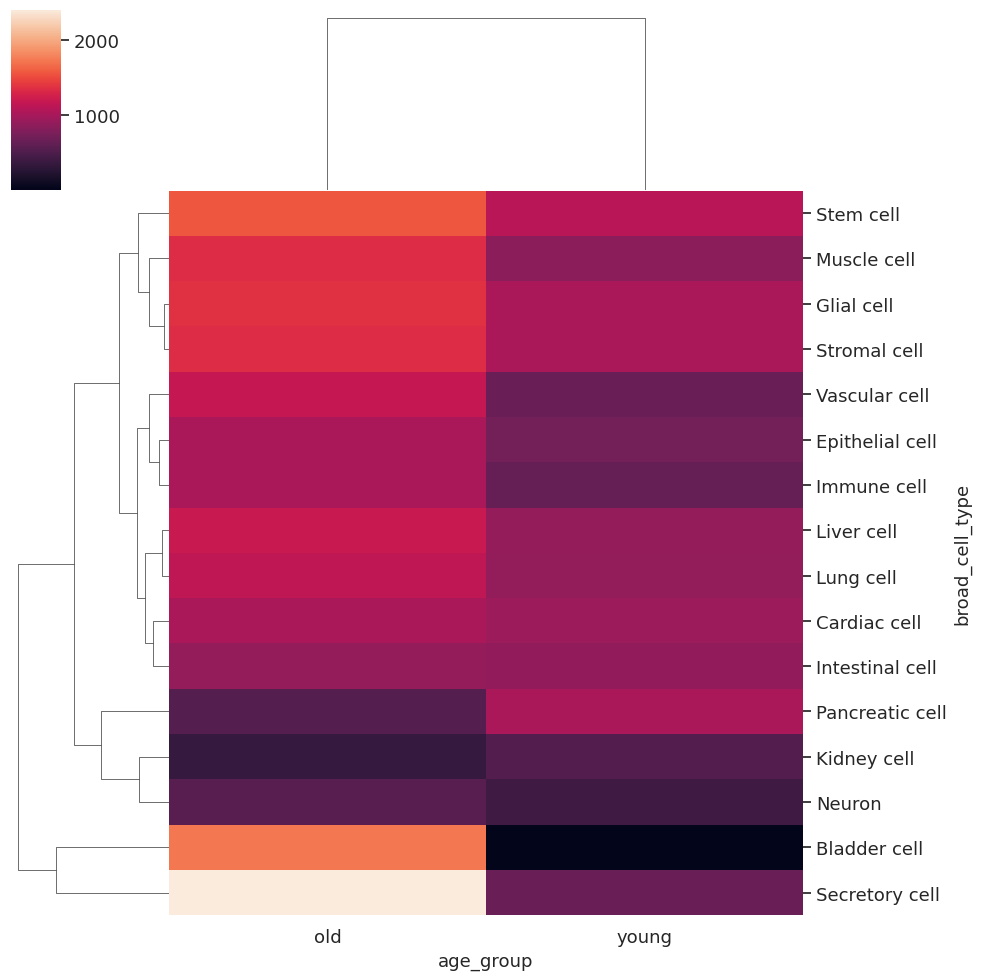

In [50]:
# make clustermap using median_read_summary broad_cell_type and age group vs median_unannotated_reads
sns.clustermap(median_read_summary[["broad_cell_type", "age_group", "median_unannotated_reads"]].pivot(index="broad_cell_type", columns="age_group", values="median_unannotated_reads"), 
               yticklabels=True, 
               xticklabels=True)

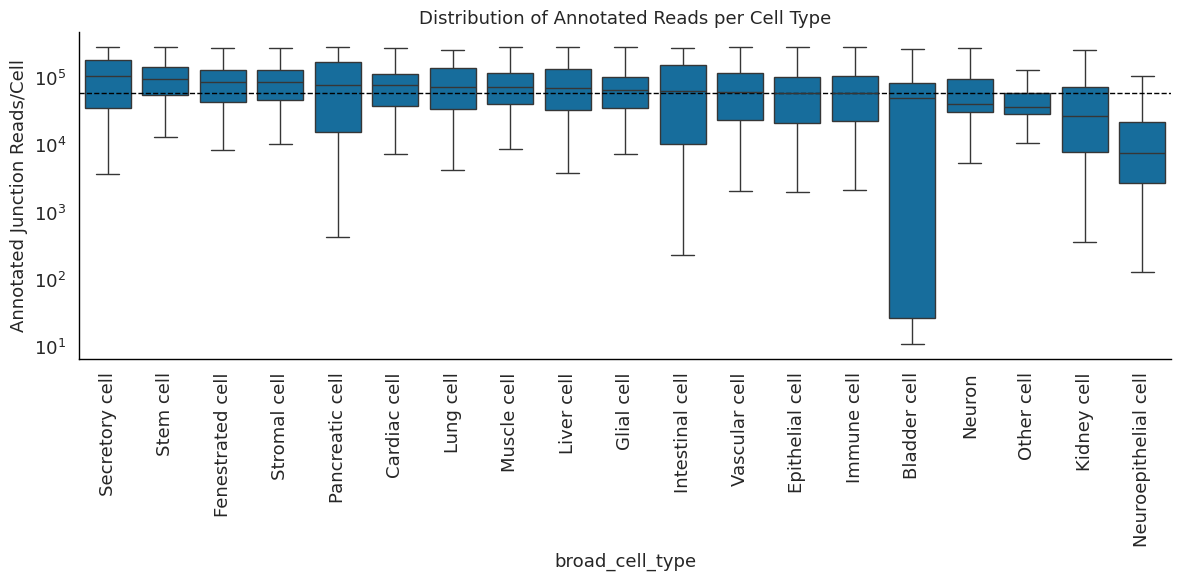

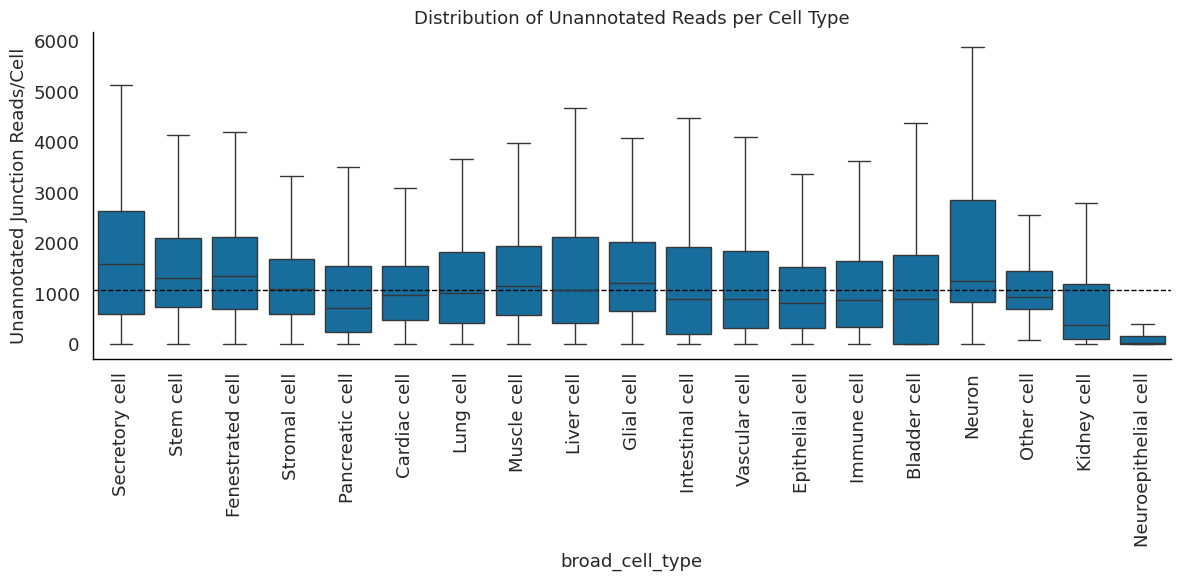

Overall median annotated reads: 60210.5
Overall median unannotated reads: 1079.0


In [51]:
# Step 1: Copy and ensure clean data
df = splice_adata_full.obs[["broad_cell_type", "annotated_junction_reads", "unannotated_junction_reads"]].copy()
df = df[df["annotated_junction_reads"].notna() & df["unannotated_junction_reads"].notna()]

# Step 2: Convert categorical cell type to string if needed
df["broad_cell_type"] = df["broad_cell_type"].astype(str)

# Get overall median annotated reads
overall_median_annotated = df["annotated_junction_reads"].median()

# Get overall median unannotated reads
overall_median_unannotated = df["unannotated_junction_reads"].median()

# Step 3: Compute median annotated reads per cell type for ordering
ordered_cell_types = (
    df.groupby("broad_cell_type")["annotated_junction_reads"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 4: Plot — Annotated
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="broad_cell_type",
    y="annotated_junction_reads",
    order=ordered_cell_types,
    showfliers=False,
    linewidth=1, 
    # log y axis 
    log_scale=True
)
plt.xticks(rotation=90)
# add dashed line for overall median annotated reads
plt.axhline(overall_median_annotated, color="black", linestyle="--", linewidth=1)
plt.ylabel("Annotated Junction Reads/Cell")
plt.title("Distribution of Annotated Reads per Cell Type")
sns.despine()
plt.tight_layout()
plt.show()

# Step 5: Plot — Unannotated (same order)
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="broad_cell_type",
    y="unannotated_junction_reads",
    order=ordered_cell_types,
    showfliers=False,
    linewidth=1
)
plt.xticks(rotation=90)
# add dashed line for overall median unannotated reads
plt.axhline(overall_median_unannotated, color="black", linestyle="--", linewidth=1)
plt.ylabel("Unannotated Junction Reads/Cell")
plt.title("Distribution of Unannotated Reads per Cell Type")
sns.despine()
plt.tight_layout()
plt.show()

print(f"Overall median annotated reads: {overall_median_annotated}")
print(f"Overall median unannotated reads: {overall_median_unannotated}")

In [63]:
splice_adata_full.obs.iloc[1]

cell_id_index                                          1
age                                                    3
cell_ontology_class                   bulge keratinocyte
mouse.id                                          3_39_F
sex                                               female
subtissue                                        Telogen
tissue                                              Skin
dataset                                              TMS
cell_name                                    A10_B000126
cell_id                                      A10_B000126
cell_clean                                   A10_B000126
specific_cell_type                    Bulge keratinocyte
broad_cell_type                          Epithelial cell
medium_cell_type                    Skin epithelial cell
seqtech                                      single_cell
library_size                                       36335
total_junction_reads                               33746
annotated_junction_reads       

In [52]:
# ---------- Shared Setup ----------
df = splice_adata_full.obs.copy()
df = df[df["age"].isin([3, 18, 24])]

group_counts = df.groupby(["broad_cell_type", "age"]).size().unstack(fill_value=0)
valid_cell_types = group_counts[(group_counts >= 50).all(axis=1)].index.astype(str)

df = df[df["broad_cell_type"].isin(valid_cell_types)]
df["broad_cell_type"] = df["broad_cell_type"].astype(str)
df["age"] = df["age"].astype(int)
age_order = [3, 18, 24]

print(df)

# Shared color palette across both plots
cell_types = sorted(valid_cell_types)  # consistent order
palette = sns.color_palette("tab20", n_colors=len(cell_types))
cell_type_color_dict = dict(zip(cell_types, palette))

              cell_id_index  age  \
cell_id                            
A10_B000120               0   18   
A10_B000126               1    3   
A10_B000127               2    3   
A10_B000166               3    3   
A10_B000169               4   18   
...                     ...  ...   
P9_MAA001887         119532    3   
P9_MAA001888         119533    3   
P9_MAA001889         119534    3   
P9_MAA001892         119535    3   
P9_MAA001894         119536    3   

                                         cell_ontology_class mouse.id     sex  \
cell_id                                                                         
A10_B000120   basal epithelial cell of tracheobronchial tree  18_47_F  female   
A10_B000126                               bulge keratinocyte   3_39_F  female   
A10_B000127                                     myeloid cell   3_38_F  female   
A10_B000166                                       basal cell   3_56_F  female   
A10_B000169              endothelial cell of 

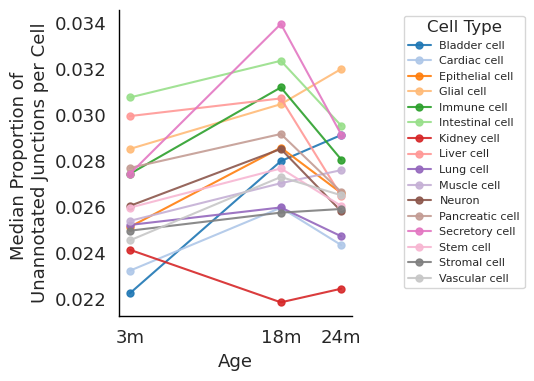

In [53]:
# Compute proportion of unannotated junctions
df["prop_unannotated_junctions"] = df["n_detected_unannotated_junctions"] / (
    df["n_detected_annotated_junctions"] + df["n_detected_unannotated_junctions"]
)

summary_junctions = (
    df.groupby(["broad_cell_type", "age"])["prop_unannotated_junctions"]
    .median()
    .reset_index()
)

summary_wide_junctions = summary_junctions.pivot(index="broad_cell_type", columns="age", values="prop_unannotated_junctions")
summary_wide_junctions = summary_wide_junctions[age_order]

# Plot
plt.figure(figsize=(6, 4))
for ct, row in summary_wide_junctions.iterrows():
    plt.plot(age_order, row.values, marker="o", label=ct,
             linewidth=1.5, markersize=5, alpha=0.9, color=cell_type_color_dict[ct])

plt.xticks(age_order, ["3m", "18m", "24m"])
plt.ylabel("Median Proportion of \nUnannotated Junctions per Cell")
plt.xlabel("Age")
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

if len(cell_types) <= 20:
    plt.legend(bbox_to_anchor=(1.2, 1), loc="upper left", fontsize=8, title="Cell Type")

plt.tight_layout()

# save plot with today 
plt.savefig(os.path.join(output_dir, f"mouse_splicing_novelty_junction_level_{today}.pdf"), format="pdf", bbox_inches="tight")
plt.show()

Text(0.5, 0, 'Age')

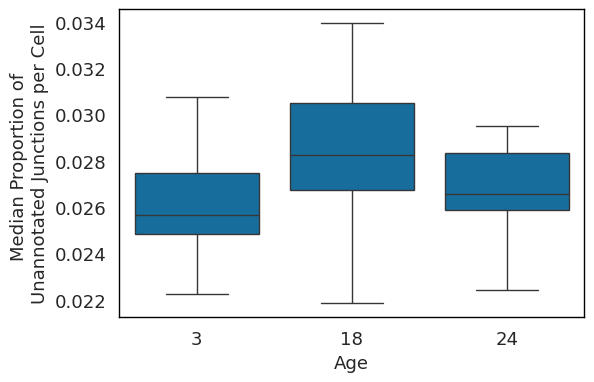

In [54]:
# use summary_junctions to make boxplot y prop_unannotated_junctions x age 
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=summary_junctions,
    x="age",
    y="prop_unannotated_junctions",
    showfliers=False,
    linewidth=1
)
plt.ylabel("Median Proportion of \nUnannotated Junctions per Cell")
plt.xlabel("Age")

# Compute proportion of unannotated reads

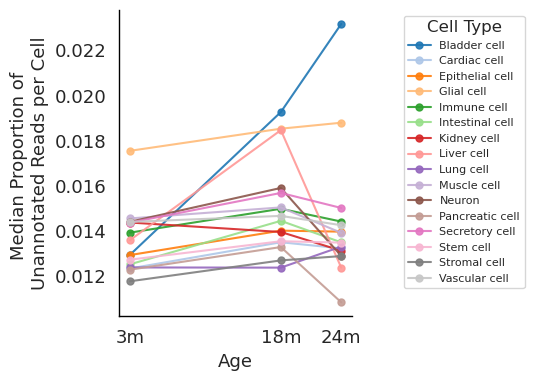

In [55]:
# Compute proportion of unannotated reads
df["prop_unannotated_reads"] = df["unannotated_junction_reads"] / (
    df["annotated_junction_reads"] + df["unannotated_junction_reads"]
)

summary_reads = (
    df.groupby(["broad_cell_type", "age"])["prop_unannotated_reads"]
    .median()
    .reset_index()
)

summary_wide_reads = summary_reads.pivot(index="broad_cell_type", columns="age", values="prop_unannotated_reads")
summary_wide_reads = summary_wide_reads[age_order]

# Plot
plt.figure(figsize=(6, 4))
for ct, row in summary_wide_reads.iterrows():
    plt.plot(age_order, row.values, marker="o", label=ct,
             linewidth=1.5, markersize=5, alpha=0.9, color=cell_type_color_dict[ct])

plt.xticks(age_order, ["3m", "18m", "24m"])
plt.ylabel("Median Proportion of \nUnannotated Reads per Cell")
plt.xlabel("Age")
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

if len(cell_types) <= 20:
    plt.legend(bbox_to_anchor=(1.2, 1), loc="upper left", fontsize=8, title="Cell Type")

plt.tight_layout()
# save plot with today 
plt.savefig(os.path.join(output_dir, f"mouse_splicing_novelty_read_level_{today}.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [56]:
output_dir

'/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper'

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_splicing_novelty_read_level_20250724.pdf


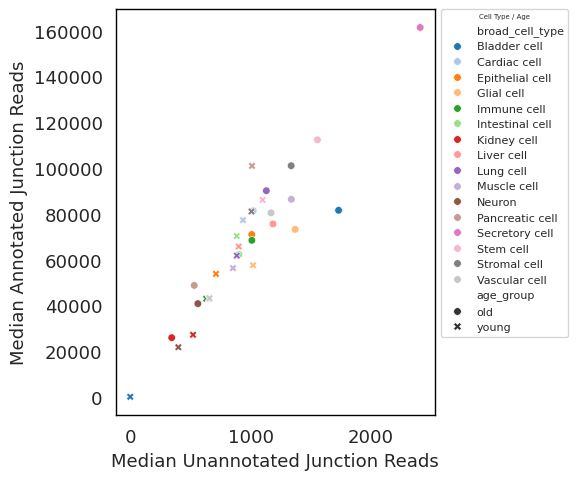

In [57]:
# Ensure `cell_type_color_dict` is defined from earlier:
# cell_type_color_dict = dict(zip(cell_types, palette))

# Plot with consistent color mapping
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=median_read_summary,
    x="median_unannotated_reads",
    y="median_annotated_reads",
    hue="broad_cell_type",
    style="age_group",
    palette=cell_type_color_dict,  # <- apply consistent colors
    s=30
)

plt.xlabel("Median Unannotated Junction Reads")
plt.ylabel("Median Annotated Junction Reads")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=8,
    title="Cell Type / Age",
    title_fontsize=5
)
# Make outline black 
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.tight_layout()

# save in output directory add today to filename
plt.savefig(os.path.join(output_dir, f"mouse_splicing_novelty_read_level_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/mouse_splicing_novelty_read_level_{today}.pdf")

plt.show()

In [58]:
# Set style
from itertools import product

sns.set_style("whitegrid", {"axes.grid": False})

# Unique values
cell_types = splice_adata_full.obs["broad_cell_type"].unique()
age_groups = splice_adata_full.obs["age_group"].unique()

# Line style map
linestyle_map = {"young": "solid", "old": "dashed"}

# Create color palette just for age groups (reused in every plot)
age_colors = dict(zip(age_groups, sns.color_palette("colorblind", len(age_groups))))

# Median lines (global)
median_annotated = splice_adata_full.obs["n_detected_unannotated_junctions"].median()

for cell_type in cell_types:
    plt.figure(figsize=(5, 4))

    for age_group in age_groups:
        subset = splice_adata_full.obs[
            (splice_adata_full.obs["broad_cell_type"] == cell_type) &
            (splice_adata_full.obs["age_group"] == age_group)
        ]

        if len(subset) < 10:
            continue

        sns.histplot(
            data=subset,
            x="n_detected_unannotated_junctions",
            stat="density",
            bins=30,
            element="step",
            fill=False,
            color=age_colors[age_group],
            linestyle=linestyle_map[age_group],
            label=f"{age_group} (n={len(subset)})",
            log_scale=(True, False),
            linewidth=1,
        )

    # Add global median reference
    plt.axvline(median_annotated, color="black", linestyle="--", linewidth=1)
    plt.text(median_annotated, plt.ylim()[1]*0.9, f"Median = {int(median_annotated)}",
             color="black", ha="center", va="top", fontsize=8)

    plt.title(cell_type)
    plt.xlabel("Detected Unannotated Junctions")
    plt.ylabel("Density")
    plt.legend(title="Age Group", fontsize=7, title_fontsize=8, loc="upper right")
    sns.despine()
    plt.tight_layout()

    # Save per cell type
    safe_cell_type = cell_type.replace(" ", "_").replace("/", "_")
    plt.savefig(os.path.join(output_dir, f"junction_detection_{safe_cell_type}_{today}.pdf"), format="pdf", bbox_inches="tight")
    print(f"Saved: {safe_cell_type}")
    plt.close()

Saved: Epithelial_cell
Saved: Immune_cell
Saved: Vascular_cell
Saved: Muscle_cell
Saved: Stem_cell
Saved: Stromal_cell
Saved: Secretory_cell
Saved: Cardiac_cell
Saved: Pancreatic_cell
Saved: Glial_cell
Saved: Liver_cell
Saved: Fenestrated_cell
Saved: Intestinal_cell
Saved: Bladder_cell
Saved: Neuron
Saved: Kidney_cell
Saved: Neuroepithelial_cell
Saved: Lung_cell
Saved: Other_cell


Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_detected_junctions_annotation_distribution_20250724.pdf


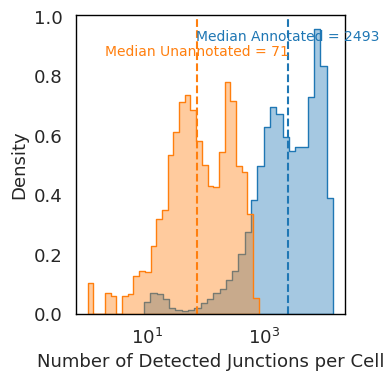

In [59]:
plt.figure(figsize=(4, 4))

# Turn off background grid
sns.set_style("whitegrid", {"axes.grid": False})

# Compute medians
median_annotated = splice_adata_full.obs["n_detected_annotated_junctions"].median()
median_unannotated = splice_adata_full.obs["n_detected_unannotated_junctions"].median()

# Annotated
sns.histplot(
    data=splice_adata_full.obs,
    x="n_detected_annotated_junctions",
    label="Annotated Junctions",
    color="tab:blue",
    element="step",
    fill=True,
    stat="density",
    bins=30,
    alpha=0.4,
    log_scale=(True, False)
)

# Unannotated
sns.histplot(
    data=splice_adata_full.obs,
    x="n_detected_unannotated_junctions",
    label="Unannotated Junctions",
    color="tab:orange",
    element="step",
    fill=True,
    stat="density",
    bins=30,
    alpha=0.4,
    log_scale=(True, False)
)

# Add vertical dashed lines for medians
plt.axvline(median_annotated, color="tab:blue", linestyle="--", linewidth=1.5)
plt.axvline(median_unannotated, color="tab:orange", linestyle="--", linewidth=1.5)

# Add text labels for medians
plt.text(median_annotated, plt.ylim()[1]*0.95, f"Median Annotated = {int(median_annotated)}",
         color="tab:blue", ha="center", va="top", fontsize=10)
plt.text(median_unannotated, plt.ylim()[1]*0.9, f"Median Unannotated = {int(median_unannotated)}",
         color="tab:orange", ha="center", va="top", fontsize=10)

plt.xlabel("Number of Detected Junctions per Cell")
plt.ylabel("Density")
# remove legend
plt.legend().remove()
# make sure black line outline is present
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.tight_layout()
# save in output directory add today to filename
plt.savefig(os.path.join(output_dir, f"mouse_detected_junctions_annotation_distribution_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/mouse_detected_junctions_annotation_distribution_{today}.pdf")
plt.show()

In [60]:
# next analysis: median(abs(deltaPSI)) between cell types is it reduced in old mice? 
# do older cells look more like each other regardless of cell type than young cells? 

# Calculate correlation matrices for young vs old
def calculate_celltype_similarity(splice_adata, age_group):
    # Get mean PSI for each cell type
    celltype_psi = {}
    for ct in splice_adata.obs["broad_cell_type"].unique():
        mask = (splice_adata.obs["broad_cell_type"] == ct) & (splice_adata.obs["age_group"] == age_group)
        if mask.sum() >= 100:  # minimum cells
            celltype_psi[ct] = np.array(splice_adata[mask].layers["junc_ratio"].mean(axis=0)).flatten()
    
    # Create correlation matrix
    celltypes = list(celltype_psi.keys())
    corr_matrix = np.zeros((len(celltypes), len(celltypes)))
    
    for i, ct1 in enumerate(celltypes):
        for j, ct2 in enumerate(celltypes):
            if i != j:
                corr_matrix[i,j] = np.corrcoef(celltype_psi[ct1], celltype_psi[ct2])[0,1]
    
    return corr_matrix, celltypes

# Compare young vs old
corr_young, ct_young = calculate_celltype_similarity(splice_adata_full, "young")
corr_old, ct_old = calculate_celltype_similarity(splice_adata_full, "old")

# Extract upper triangle (excluding diagonal)
young_corrs = corr_young[np.triu_indices_from(corr_young, k=1)]
old_corrs = corr_old[np.triu_indices_from(corr_old, k=1)]

# Test if old cells are more correlated
print(f"Mean correlation young: {young_corrs.mean():.3f}")
print(f"Mean correlation old: {old_corrs.mean():.3f}")


Mean correlation young: 0.732
Mean correlation old: 0.744


### Otherway, is differential splicing signal stronger in younger cells (for ex liver vs kidney) than if you were to check DS in older cells for same cell type... 
- delta PSI pairwise across cell types within young and old 
- cell type by cell type heatmap of avg delta psi between those two cell types and another version for old  

In [61]:
# Your existing approach but modified to compare cell types within tissues
delta_between_celltypes = {}

for tissue in splice_adata_full.obs["tissue"].unique():
    if tissue == "Brain_Non-Myeloid":
        continue
        
    tissue_mask = splice_adata_full.obs["tissue"] == tissue
    tissue_data = splice_adata_full[tissue_mask]
    
    # Get unique cell types in this tissue
    celltypes = tissue_data.obs["cell_type"].unique()
    
    # Calculate pairwise delta PSI between cell types for young and old
    for age in ["young", "old"]:
        age_mask = tissue_data.obs["age_group"] == age
        age_data = tissue_data[age_mask]
        
        ct_deltas = []
        for i, ct1 in enumerate(celltypes):
            for j, ct2 in enumerate(celltypes):
                if i < j:  # Only upper triangle
                    mask1 = age_data.obs["cell_type"] == ct1
                    mask2 = age_data.obs["cell_type"] == ct2
                    
                    if mask1.sum() >= 50 and mask2.sum() >= 50:
                        psi1 = np.array(age_data[mask1].layers["junc_ratio"].mean(axis=0)).flatten()
                        psi2 = np.array(age_data[mask2].layers["junc_ratio"].mean(axis=0)).flatten()
                        
                        delta = np.abs(psi1 - psi2)
                        ct_deltas.append(np.median(delta))
        
        if ct_deltas:
            delta_between_celltypes[f"{tissue}_{age}"] = np.mean(ct_deltas)

# Compare young vs old
young_deltas = [v for k, v in delta_between_celltypes.items() if "_young" in k]
old_deltas = [v for k, v in delta_between_celltypes.items() if "_old" in k]

print(f"Mean delta PSI between cell types (young): {np.mean(young_deltas):.3f}")
print(f"Mean delta PSI between cell types (old): {np.mean(old_deltas):.3f}")

KeyError: 'cell_type'